# 03 · Evaluación del modelo — Predictor UFC

Evaluación **honesta** de los modelos con **split temporal**: se entrena con peleas antiguas y se prueba con las más recientes (2024–2026), imitando la predicción de peleas futuras. Ninguna feature usa información posterior a la fecha de cada pelea (sin *data leakage*).

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
if not (root / 'config.py').exists():
    root = root.parent
sys.path.insert(0, str(root))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import config
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.grid'] = True
import joblib
from src.models.train import _split_temporal, _features
from sklearn.metrics import (roc_curve, roc_auc_score, accuracy_score,
    log_loss, brier_score_loss, confusion_matrix, classification_report)


In [2]:
df = pd.read_csv(config.DATASET_CSV)
art = joblib.load(config.MODEL_PATH)
train, valid, test = _split_temporal(df)
Xte, yte = _features(test), test['label']
print(f'train={len(train)}  valid={len(valid)}  test={len(test)}')
print('test desde:', pd.to_datetime(test.date).min().date())

train=12054  valid=2558  test=2576
test desde: 2024-01-20


## Modelo de ganador
Métricas en el conjunto de test temporal.

In [3]:
p = art['winner'].predict_proba(Xte)[:, 1]
print(f"Accuracy : {accuracy_score(yte, p > 0.5):.3f}")
print(f"ROC-AUC  : {roc_auc_score(yte, p):.3f}")
print(f"LogLoss  : {log_loss(yte, p):.3f}")
print(f"Brier    : {brier_score_loss(yte, p):.3f}")

Accuracy : 0.619
ROC-AUC  : 0.666
LogLoss  : 0.651
Brier    : 0.230


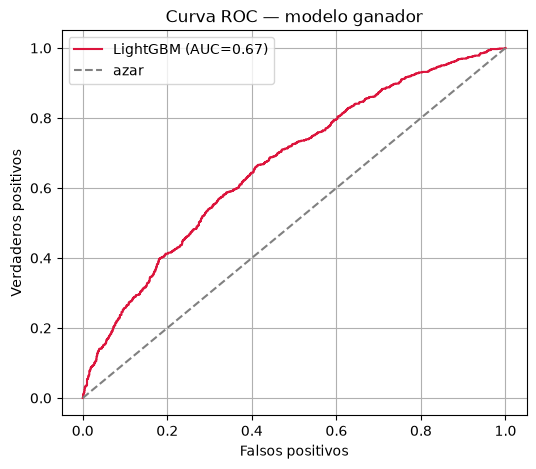

In [4]:
fpr, tpr, _ = roc_curve(yte, p)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='crimson', label=f'LightGBM (AUC={roc_auc_score(yte, p):.2f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='azar')
plt.xlabel('Falsos positivos'); plt.ylabel('Verdaderos positivos')
plt.title('Curva ROC — modelo ganador'); plt.legend(); plt.show()

### ¿Están bien calibradas las probabilidades?
Si el modelo dice '70%', ¿gana el 70% de esas veces? La curva pegada a la diagonal indica buena calibración — por eso **no** hizo falta calibración isotónica extra.

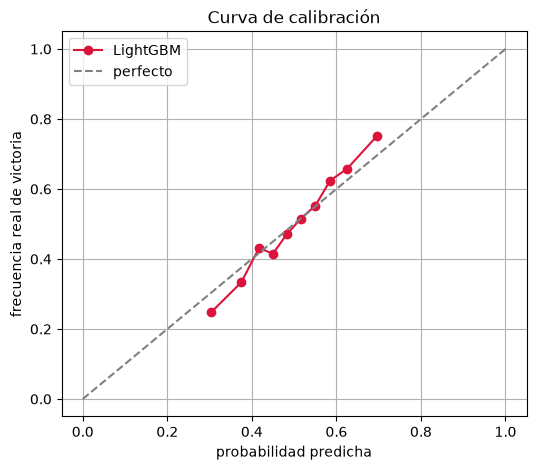

In [5]:
from sklearn.calibration import calibration_curve
frac, mean = calibration_curve(yte, p, n_bins=10, strategy='quantile')
plt.figure(figsize=(6, 5))
plt.plot(mean, frac, 'o-', color='crimson', label='LightGBM')
plt.plot([0, 1], [0, 1], '--', color='gray', label='perfecto')
plt.xlabel('probabilidad predicha'); plt.ylabel('frecuencia real de victoria')
plt.title('Curva de calibración'); plt.legend(); plt.show()

## Modelo de método
Matriz de confusión y reporte por clase (KO/TKO, SUB, DEC).

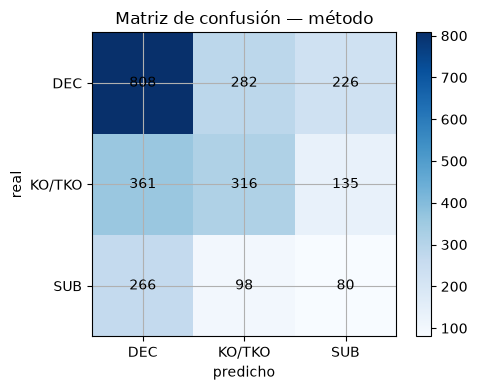

              precision    recall  f1-score   support

         DEC      0.563     0.614     0.587      1316
      KO/TKO      0.454     0.389     0.419       812
         SUB      0.181     0.180     0.181       444

    accuracy                          0.468      2572
   macro avg      0.399     0.394     0.396      2572
weighted avg      0.463     0.468     0.464      2572



In [6]:
te = test[test.method != 'OTHER']
Xm, ym = _features(te), te['method']
pred = art['method'].predict(Xm)
labels = list(art['method'].classes_)
cm = confusion_matrix(ym, pred, labels=labels)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.xticks(range(len(labels)), labels); plt.yticks(range(len(labels)), labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.xlabel('predicho'); plt.ylabel('real'); plt.title('Matriz de confusión — método')
plt.colorbar(); plt.tight_layout(); plt.show()
print(classification_report(ym, pred, digits=3, zero_division=0))

## ¿Qué features pesan más?
Importancia de las variables en el modelo de ganador (todas son **diferencias A − B** de estadísticas pre-pelea).

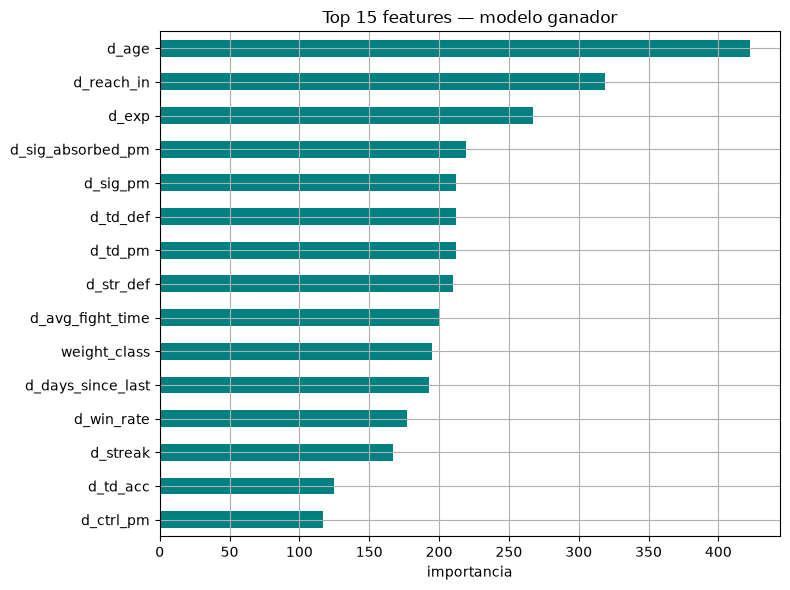

In [7]:
imp = (pd.Series(art['winner'].feature_importances_, index=art['feature_cols'])
       .sort_values().tail(15))
plt.figure(figsize=(8, 6))
imp.plot(kind='barh', color='teal')
plt.title('Top 15 features — modelo ganador'); plt.xlabel('importancia'); plt.tight_layout(); plt.show()

## Conclusiones
- **Accuracy ~0.62 / AUC ~0.67** en test temporal: sólido para predicción de UFC solo con datos pre-pelea (la literatura ronda 60–65%).
- Probabilidades **bien calibradas** sin post-procesamiento.
- El método es más difícil (macro-F1 ~0.40), pero el modelo da una **distribución** útil sobre KO/TKO, SUB y DEC.
- La evaluación es **honesta**: split temporal + features sin fuga de datos. El número refleja lo que se puede esperar en peleas futuras reales.